<a href="https://colab.research.google.com/github/gnix22/Summer_Research_2024/blob/main/simulation_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("distr")
install.packages("e1071")
install.packages("pracma")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘startupmsg’, ‘sfsmisc’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(distr)
library(e1071)
set.seed(42)
to_b1 <- function(alpha, sigma) alpha / sigma
to_b2 <- function(mu, sigma) mu / sigma

pdf_ncbl <- function(x, mu, sigma, alpha, lamb) {
  f_r <- (2*atanh(1-2*lamb)*(lamb^x)*((1-lamb)^(1-x))) / (1-(2*lamb))
  F_r <- ((lamb^x) * ((1-lamb)^(1-x)) + lamb - 1) / ((2*lamb) - 1)
  s_r <- 1 - F_r
  z   <- exp(-(alpha * log(F_r / s_r) - mu)^2 / (2 * sigma^2))
  (alpha * f_r * z) / (sigma * sqrt(2*pi) * F_r * s_r)
}

params <- list(
  c(mu = 0.3, sigma = 0.4, alpha = 0.9, lambda = 0.4),
  c(mu = 0.1, sigma = 0.9, alpha = 0.9, lambda = 0.1),
  c(mu = 0.1, sigma = 0.9, alpha = 0.9, lambda = 0.9),
  c(mu = 0.1, sigma = 0.9, alpha = 0.474, lambda = 0.68),
  c(mu = 0.1, sigma = 0.9, alpha = 0.5,   lambda = 0.1),
  c(mu = 0.1, sigma = 0.5, alpha = 0.9,   lambda = 0.1),
  c(mu = 0.1, sigma = 0.5, alpha = 0.9,   lambda = 0.9)
)

results <- lapply(params, function(p) {
  pdf_safe <- function(x) {
    y <- numeric(length(x))
    valid <- x > 0 & x < 1
    if (any(valid))
      y[valid] <- pdf_ncbl(x[valid], p["mu"], p["sigma"], p["alpha"], p["lambda"])
    y[is.na(y) | is.nan(y) | !is.finite(y)] <- 0
    y
  }

  my_dist <- AbscontDistribution(d = pdf_safe)
  samples <- r(my_dist)(1e6)

  data.frame(
    beta1    = to_b1(p["alpha"], p["sigma"]),
    beta2    = to_b2(p["mu"],    p["sigma"]),
    lambda   = p["lambda"],
    mean     = mean(samples),
    variance = var(samples),
    skewness = skewness(samples),
    kurtosis = kurtosis(samples)
  )
})

do.call(rbind, results)

,beta1,beta2,lambda,mean,variance,skewness,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alpha,2.2500000,0.7500000,0.40,0.5310596,0.011120742,-0.07387602,-0.3003615
alpha1,1.0000000,0.1111111,0.10,0.3156470,0.030743490,0.63174754,-0.1805513
alpha2,1.0000000,0.1111111,0.90,0.7214654,0.027435115,-0.78504920,0.1486124
alpha3,0.5266667,0.1111111,0.68,0.5907983,0.089014141,-0.35796083,-1.1738522
alpha4,0.5555556,0.1111111,0.10,0.3629463,0.074242956,0.53770649,-0.8691120
alpha5,1.8000000,0.2000000,0.10,0.2980304,0.010606208,0.49439083,0.0553495
alpha6,1.8000000,0.2000000,0.90,0.7414302,0.009130427,-0.61001726,0.2780878


# Simulation study of NCBL

In [ ]:
nll_ncbl <- function(params, x){
  mu <- params[1]; sigma <- params[2]; alpha <- params[3]; lambda <- params[4];
  -sum(log(pdf_ncbl(x,mu,sigma,alpha,lambda)))
}
# gather samples from ncbl
#X <- function(x, m, s, a, l) {
#  T_samples <- rnorm(x, mean = m, sd = s)
#  num <- log(3 * l * exp(T_samples / a) - l + 1) -
#         log(1 + exp(T_samples / a)) - log(1 - l)
#  den <- log(l) - log(1 - l)
#  pmax(pmin(num / den, 1 - 1e-9), 1e-9)
#}

#X <- function(x, m, s, a, l) {
#  T_samples <- rnorm(x, mean = m, sd = s)
#  num <- log(3 * l * exp(T_samples / a) - l + 1) - log(1 + exp(T_samples / a))- log(1-l)
#  den <- log(l) - log(1 - l)
#  pmax(pmin(num / den, 1 - 1e-6), 1e-6)  # looser clamp
#}

pdf_ncbl <- function(x, mu, sigma, alpha, lamb) {
  f_r <- (2*atanh(1-2*lamb)*(lamb^x)*((1-lamb)^(1-x))) / (1-(2*lamb))
  F_r <- ((lamb^x) * ((1-lamb)^(1-x)) + lamb - 1) / ((2*lamb) - 1)
  s_r <- 1 - F_r
  F_r <- pmax(pmin(F_r, 1 - 1e-10), 1e-10)
  s_r <- pmax(pmin(s_r, 1 - 1e-10), 1e-10)
  z   <- exp(-(alpha * log(F_r / s_r) - mu)^2 / (2 * sigma^2))
  (alpha * f_r * z) / (sigma * sqrt(2*pi) * F_r * s_r)
}

fit_model <- function(nll, data, init = c(0.3, 0.4, 0.9, 0.28)) {
  fit <- tryCatch(
    optim(
      par    = init,
      fn     = nll,
      x      = data,
      method = "L-BFGS-B",
      lower  = c(-Inf, 1e-6, 1e-6, 1e-6),
      upper  = c( Inf,  Inf,  Inf, 1-1e-6)
    ),
    error = function(e) NULL
  )
  if (is.null(fit) || fit$convergence != 0) return(NULL)
  fit$par
}

In [ ]:
X <- function(x, m, s, a, l) {
  T_samples <- rnorm(x, mean = m, sd = s)

  p <- plogis(T_samples / a)

  num <- log(p * (2*l - 1) + 1 - l) - log(1 - l)
  den <- log(l) - log(1 - l)

  pmax(pmin(num / den, 1 - 1e-6), 1e-6)
}

range: 0.1466672 0.8063495 


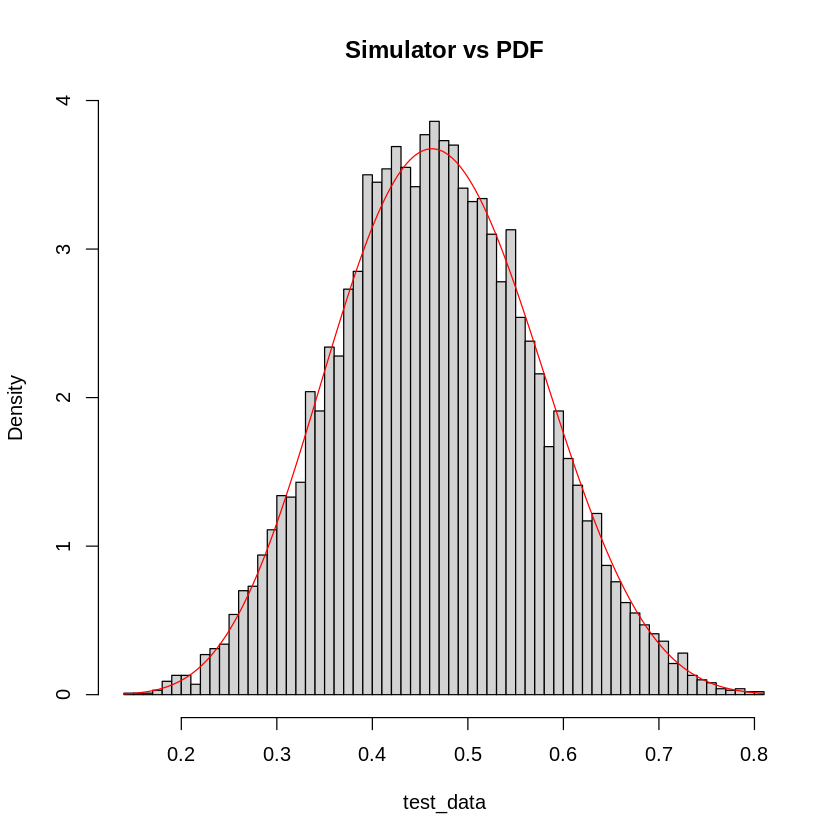

In [ ]:
test_data <- X(10000, m = 0.3, s = 0.4, a = 0.9, l = 0.28)
cat("range:", range(test_data), "\n")
hist(test_data, breaks = 50, freq = FALSE, main = "Simulator vs PDF")
curve(pdf_ncbl(x, mu = 0.3, sigma = 0.4, alpha = 0.9, lamb = 0.28),
      add = TRUE, col = "red", n = 200)

In [ ]:
run_simulation <- function(true_params,
                           sample_sizes = c(50, 100, 200, 500, 1000),
                           n_rep = 1000, seed = 42) {
  set.seed(seed)
  mu_t     <- true_params["mu"]
  sigma_t  <- true_params["sigma"]
  alpha_t  <- true_params["alpha"]
  lambda_t <- true_params["lambda"]

  results <- list()
  for (n in sample_sizes) {
    cat(sprintf("n = %d\n", n))

    ests <- replicate(n_rep, {
      data <- X(n, mu_t, sigma_t, alpha_t, lambda_t)
      fit  <- fit_model(nll_ncbl, data)
      if (is.null(fit)) rep(NA, 4) else fit
    })

    ests <- t(ests)
    n_converged <- sum(complete.cases(ests))
    ests <- ests[complete.cases(ests), , drop = FALSE]  # fix is here
    colnames(ests) <- c("mu", "sigma", "alpha", "lambda")

    if (n_converged == 0) {
      cat(sprintf("  no convergences at n = %d, skipping\n", n))
      results[[as.character(n)]] <- data.frame(
        n           = n,
        parameter   = c("mu", "sigma", "alpha", "lambda"),
        true_value  = true_params,
        mean_est    = NA,
        bias        = NA,
        rmse        = NA,
        n_converged = 0
      )
      next
    }

    bias <- colMeans(ests) - true_params
    rmse <- sqrt(colMeans(sweep(ests, 2, true_params)^2))

    results[[as.character(n)]] <- data.frame(
      n           = n,
      parameter   = c("mu", "sigma", "alpha", "lambda"),
      true_value  = true_params,
      mean_est    = colMeans(ests),
      bias        = bias,
      rmse        = rmse,
      n_converged = n_converged
    )
  }
  do.call(rbind, results)
}

true_params <- c(mu = 0.3, sigma = 0.4, alpha = 0.9, lambda = 0.28)

cat("\n=== MLE Simulation: N-CB{logistic} ===\n")
print(run_simulation(true_params), digits = 4)


=== MLE Simulation: N-CB{logistic} ===
n = 50
n = 100
n = 200
n = 500
n = 1000
               n parameter true_value mean_est      bias    rmse n_converged
50.mu         50        mu       0.30   0.2783 -0.021690 0.63961         966
50.sigma      50     sigma       0.40   0.4360  0.036047 0.11523         966
50.alpha      50     alpha       0.90   0.9684  0.068365 0.31233         966
50.lambda     50    lambda       0.28   0.3362  0.056189 0.21534         966
100.mu       100        mu       0.30   0.3108  0.010791 0.69318         967
100.sigma    100     sigma       0.40   0.4392  0.039177 0.13867         967
100.alpha    100     alpha       0.90   0.9674  0.067362 0.33640         967
100.lambda   100    lambda       0.28   0.3271  0.047146 0.21280         967
200.mu       200        mu       0.30   0.3591  0.059086 0.69498         960
200.sigma    200     sigma       0.40   0.4319  0.031852 0.14211         960
200.alpha    200     alpha       0.90   0.9418  0.041820 0.31274         

In [ ]:
run_simulation <- function(true_params,
                           sample_sizes = c(50, 100, 200, 500, 1000),
                           n_rep = 1000, seed = 42) {
  set.seed(seed)
  mu_t     <- true_params["mu"]
  sigma_t  <- true_params["sigma"]
  alpha_t  <- true_params["alpha"]
  lambda_t <- true_params["lambda"]

  # True values in beta parameterization for reporting
  true_beta <- c(
    beta1  = to_b1(alpha_t, sigma_t),
    beta2  = to_b2(mu_t,    sigma_t),
    lambda = lambda_t
  )

  results <- list()
  for (n in sample_sizes) {
    cat(sprintf("n = %d\n", n))

    ests <- replicate(n_rep, {
      data <- X(n, mu_t, sigma_t, alpha_t, lambda_t)
      fit  <- fit_model(nll_ncbl, data)
      if (is.null(fit)) rep(NA, 4) else fit
    })

    ests <- t(ests)
    n_converged <- sum(complete.cases(ests))
    ests <- ests[complete.cases(ests), , drop = FALSE]
    colnames(ests) <- c("mu", "sigma", "alpha", "lambda")

    if (n_converged == 0) {
      cat(sprintf("  no convergences at n = %d, skipping\n", n))
      results[[as.character(n)]] <- data.frame(
        n           = n,
        parameter   = c("beta1", "beta2", "lambda"),
        true_value  = true_beta,
        mean_est    = NA,
        bias        = NA,
        rmse        = NA,
        n_converged = 0
      )
      next
    }

    # Convert estimates to beta parameterization
    ests_beta <- cbind(
      beta1  = ests[, "alpha"] / ests[, "sigma"],
      beta2  = ests[, "mu"]    / ests[, "sigma"],
      lambda = pmax(pmin(ests[, "lambda"], 1 - 1e-6), 1e-6)
    )

    bias <- colMeans(ests_beta) - true_beta
    rmse <- sqrt(colMeans(sweep(ests_beta, 2, true_beta)^2))

    results[[as.character(n)]] <- data.frame(
      n           = n,
      parameter   = c("beta1", "beta2", "lambda"),
      true_value  = true_beta,
      mean_est    = colMeans(ests_beta),
      bias        = bias,
      rmse        = rmse,
      n_converged = n_converged
    )
  }
  do.call(rbind, results)
}

param_sets <- list(
  c(mu = 0.3, sigma = 0.4, alpha = 0.9,   lambda = 0.4),
  c(mu = 0.1, sigma = 0.9, alpha = 0.9,   lambda = 0.1),
  c(mu = 0.1, sigma = 0.9, alpha = 0.9,   lambda = 0.9),
  c(mu = 0.1, sigma = 0.9, alpha = 0.474, lambda = 0.68),
  c(mu = 0.1, sigma = 0.9, alpha = 0.5,   lambda = 0.1),
  c(mu = 0.1, sigma = 0.5, alpha = 0.9,   lambda = 0.1),
  c(mu = 0.1, sigma = 0.5, alpha = 0.9,   lambda = 0.9)
)

cat("\n=== MLE Simulation: N-CB{logistic} ===\n")
for (i in seq_along(param_sets)) {
  p <- param_sets[[i]]
  cat(sprintf("\n--- Parameter set %d: mu=%.1f sigma=%.1f alpha=%.3f lambda=%.2f ---\n",
              i, p["mu"], p["sigma"], p["alpha"], p["lambda"]))
  print(run_simulation(p), digits = 4)
}


=== MLE Simulation: N-CB{logistic} ===

--- Parameter set 1: mu=0.3 sigma=0.4 alpha=0.900 lambda=0.40 ---
n = 50
n = 100
n = 200
n = 500
n = 1000
                      n parameter true_value mean_est     bias   rmse
50.beta1.alpha       50     beta1       2.25   2.1939 -0.05614 0.3065
50.beta2.mu          50     beta2       0.75   1.2101  0.46013 1.4386
50.lambda.lambda     50    lambda       0.40   0.3573 -0.04271 0.2003
100.beta1.alpha     100     beta1       2.25   2.1765 -0.07351 0.2418
100.beta2.mu        100     beta2       0.75   1.3044  0.55436 1.4222
100.lambda.lambda   100    lambda       0.40   0.3372 -0.06282 0.2025
200.beta1.alpha     200     beta1       2.25   2.1571 -0.09287 0.2229
200.beta2.mu        200     beta2       0.75   1.3959  0.64586 1.4256
200.lambda.lambda   200    lambda       0.40   0.3186 -0.08142 0.2046
500.beta1.alpha     500     beta1       2.25   2.1826 -0.06741 0.1677
500.beta2.mu        500     beta2       0.75   1.2448  0.49475 1.1677
500.lambda.la

In [ ]:
library(distr)
library(e1071)
library(pracma)
set.seed(42)

f <- function(x, m, s, l) {
  FR <- ((l^x) * ((1 - l)^(1 - x)) + l - 1) / ((2 * l) - 1)
  e1 <- pi * (FR - 0.5)
  e2 <- -(1 - l)^(1 - x)
  e3 <- log((1 - l) / l)
  numerator <- exp(-((m - tan(e1))^2) / (2 * (s^2))) * sqrt(pi / 2) * e2 * (l^x) * e3 * (sec(e1))^2
  denominator <- ((2 * l) - 1) * s
  numerator / denominator
}

params <- list(
  c(mu = -2.0, sigma = 0.5, lambda = 0.3),
  c(mu = -1.5, sigma = 0.5, lambda = 0.6),
  c(mu = 0.2, sigma = 0.45, lambda = 0.15),
  c(mu = -0.3, sigma = 2.0, lambda = 0.6),
  c(mu = 0.7, sigma = 0.5, lambda = 0.9),
  c(mu = 1.5, sigma = 0.5, lambda = 0.9),
  c(mu = 0.0, sigma = 0.2, lambda = 0.55)
)

results <- lapply(params, function(p) {
  pdf_safe <- function(x) {
    y <- numeric(length(x))
    valid <- x > 0 & x < 1
    if (any(valid))
      y[valid] <- f(x[valid], p["mu"], p["sigma"], p["lambda"])
    y[is.na(y) | is.nan(y) | !is.finite(y)] <- 0
    y
  }

  my_dist <- AbscontDistribution(d = pdf_safe)
  samples <- r(my_dist)(1e6)

  data.frame(
    mu = p["mu"],
    sigma = p["sigma"],
    lambda = p["lambda"],
    mean = mean(samples),
    variance = var(samples),
    skewness = skewness(samples),
    kurtosis = kurtosis(samples)
  )
})

do.call(rbind, results)

,mu,sigma,lambda,mean,variance,skewness,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mu,-2.0,0.50,0.30,0.1094320,0.0007891688,1.62046444,5.3936810
mu1,-1.5,0.50,0.60,0.2334110,0.0041345175,1.36160421,3.0204506
mu2,0.2,0.45,0.15,0.3616396,0.0115616129,0.12402512,-0.6195299
mu3,-0.3,2.00,0.60,0.4915504,0.0855209730,0.11767113,-1.5318793
mu4,0.7,0.50,0.90,0.8393487,0.0046013626,-1.30826734,2.0250795
mu5,1.5,0.50,0.90,0.9103395,0.0009223626,-1.90996005,6.6291951
mu6,0.0,0.20,0.55,0.5247228,0.0037485040,-0.03527041,-0.2408084


In [3]:
library(pracma)
pdf_ncbc <- function(x, mu, sigma, lambda) {
  FR  <- ((lambda^x) * ((1 - lambda)^(1 - x)) + lambda - 1) / ((2 * lambda) - 1)
  e1  <- pi * (FR - 0.5)
  e2  <- -(1 - lambda)^(1 - x)
  e3  <- log((1 - lambda) / lambda)
  numerator   <- exp(-((mu - tan(e1))^2) / (2 * (sigma^2))) * sqrt(pi / 2) * e2 * (lambda^x) * e3 * (sec(e1))^2
  denominator <- ((2 * lambda) - 1) * sigma
  numerator / denominator
}

X_cauchy <- function(n, mu, sigma, lambda) {
  T_samples <- rnorm(n, mean = mu, sd = sigma)
  p <- (1/pi) * atan(T_samples) + 0.5
  num <- log(p * (2 * lambda - 1) + 1 - lambda) - log(1 - lambda)
  den <- log(lambda) - log(1 - lambda)

  pmax(pmin(num / den, 1 - 1e-6), 1e-6)
}

nll_ncbc <- function(params, x) {
  mu     <- params[1]
  sigma  <- params[2]
  lambda <- params[3]
  -sum(log(pdf_ncbc(x, mu, sigma, lambda)))
}

fit_model_ncbc <- function(data, init = c(0, 0.5, 0.5)) {
  fit <- tryCatch(
    optim(
      par    = init,
      fn     = nll_ncbc,
      x      = data,
      method = "L-BFGS-B",
      lower  = c(-Inf, 1e-6, 1e-6),
      upper  = c( Inf,  Inf,  1 - 1e-6)
    ),
    error = function(e) NULL
  )
  if (is.null(fit) || fit$convergence != 0) return(NULL)
  fit$par
}

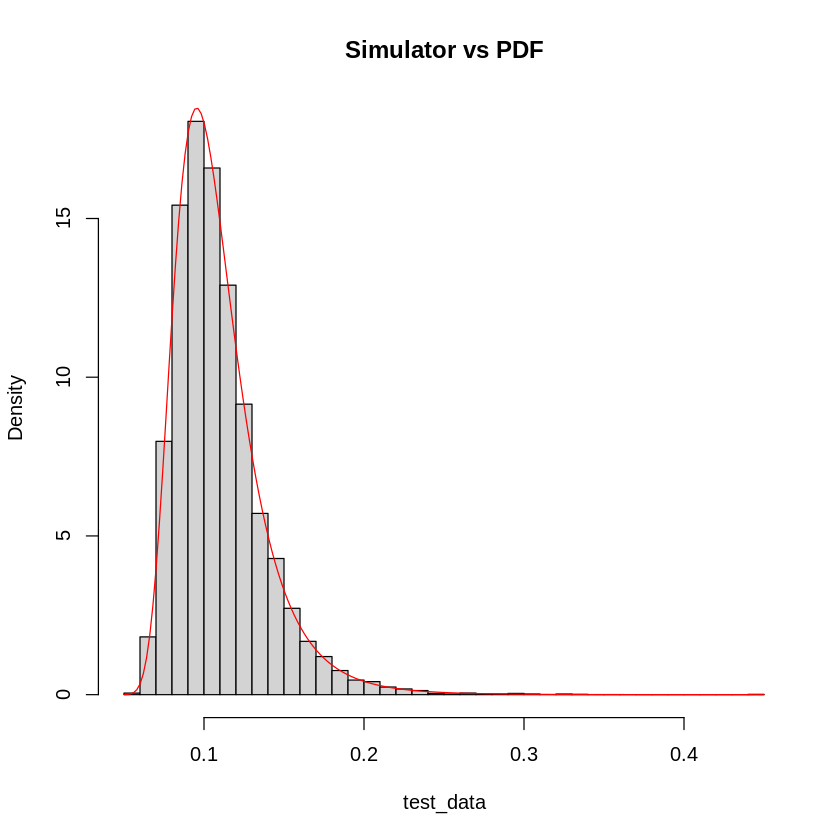

In [4]:
test_data <- X_cauchy(10000, mu = -2.0, sigma = 0.5, lambda = 0.3)
hist(test_data, breaks = 50, freq = FALSE, main = "Simulator vs PDF")
curve(pdf_ncbc(x, mu = -2.0, sigma = 0.5, lambda = 0.3),
      add = TRUE, col = "red", n = 200)

In [5]:
run_simulation_ncbc <- function(true_params,
                                sample_sizes = c(50, 100, 200, 500, 1000),
                                n_rep = 1000, seed = 42) {
  set.seed(seed)
  mu_t     <- true_params["mu"]
  sigma_t  <- true_params["sigma"]
  lambda_t <- true_params["lambda"]

  results <- list()
  for (n in sample_sizes) {
    cat(sprintf("n = %d\n", n))

    ests <- replicate(n_rep, {
      data <- X_cauchy(n, mu_t, sigma_t, lambda_t)
      fit  <- fit_model_ncbc(data, init = c(mu_t, sigma_t, lambda_t))
      if (is.null(fit)) rep(NA, 3) else fit
    })

    ests <- t(ests)
    n_converged <- sum(complete.cases(ests))
    ests <- ests[complete.cases(ests), , drop = FALSE]
    colnames(ests) <- c("mu", "sigma", "lambda")

    if (n_converged == 0) {
      cat(sprintf("  no convergences at n = %d, skipping\n", n))
      results[[as.character(n)]] <- data.frame(
        n           = n,
        parameter   = c("mu", "sigma", "lambda"),
        true_value  = true_params,
        mean_est    = NA,
        bias        = NA,
        rmse        = NA,
        n_converged = 0
      )
      next
    }

    bias <- colMeans(ests) - true_params
    rmse <- sqrt(colMeans(sweep(ests, 2, true_params)^2))

    results[[as.character(n)]] <- data.frame(
      n           = n,
      parameter   = c("mu", "sigma", "lambda"),
      true_value  = true_params,
      mean_est    = colMeans(ests),
      bias        = bias,
      rmse        = rmse,
      n_converged = n_converged
    )
  }
  do.call(rbind, results)
}

param_sets <- list(
  c(mu = -2.0, sigma = 0.5,  lambda = 0.30),
  c(mu = -1.5, sigma = 0.5,  lambda = 0.60),
  c(mu =  0.2, sigma = 0.45, lambda = 0.15),
  c(mu = -0.3, sigma = 2.0,  lambda = 0.60),
  c(mu =  0.7, sigma = 0.5,  lambda = 0.90),
  c(mu =  1.5, sigma = 0.5,  lambda = 0.90),
  c(mu =  0.0, sigma = 0.2,  lambda = 0.55)
)

cat("\n=== MLE Simulation: N-CB{Cauchy} ===\n")
for (i in seq_along(param_sets)) {
  p <- param_sets[[i]]
  cat(sprintf("\n--- Parameter set %d: mu=%.1f sigma=%.2f lambda=%.2f ---\n",
              i, p["mu"], p["sigma"], p["lambda"]))
  print(run_simulation_ncbc(p), digits = 4)
}


=== MLE Simulation: N-CB{Cauchy} ===

--- Parameter set 1: mu=-2.0 sigma=0.50 lambda=0.30 ---
n = 50
n = 100
n = 200
n = 500
n = 1000
               n parameter true_value mean_est     bias   rmse n_converged
50.mu         50        mu       -2.0  -2.8300 -0.83005 3.1174         862
50.sigma      50     sigma        0.5   0.7381  0.23813 0.7442         862
50.lambda     50    lambda        0.3   0.3215  0.02151 0.3266         862
100.mu       100        mu       -2.0  -2.7609 -0.76087 2.7524         895
100.sigma    100     sigma        0.5   0.7110  0.21100 0.6544         895
100.lambda   100    lambda        0.3   0.3301  0.03010 0.3085         895
200.mu       200        mu       -2.0  -2.6684 -0.66842 2.2514         916
200.sigma    200     sigma        0.5   0.6787  0.17871 0.5296         916
200.lambda   200    lambda        0.3   0.3484  0.04841 0.2802         916
500.mu       500        mu       -2.0  -2.3766 -0.37657 1.4780         890
500.sigma    500     sigma        0.5   